# 步驟四：建立預測模型 
最後，我們想建立一個模型，當經濟損失的資料不可知時，能夠由其他資料預測經濟損失，我們選用透過Random Forest的方法來建立模型。
也分析對經濟損失來說，重要的幾個因子

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import os


# 檢查目前是不是在 notebooks 資料夾裡，如果是，就退回/workspace
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
# 載入自訂模組
BASE_DIR = Path.cwd() 
sys.path.append(str(BASE_DIR))
from src.modeling import run_random_forest_classification


# 讀取乾淨資料
file_path = BASE_DIR / 'data' / 'processed' / 'global_climate_events_economic_impact_2020_2025_processed.csv'
df = pd.read_csv(file_path)

In [56]:
# 1. 建立分類標籤 (Target Variable)
# 將經濟損失的前 20% (第 80 百分位數) 定義為 "巨災 (1)"，其餘為 "一般災害 (0)"
threshold = df['economic_impact_million_usd'].quantile(0.80)
df['is_extreme_disaster'] = (df['economic_impact_million_usd'] >= threshold).astype(int)

# 2. 準備特徵矩陣 (X) 與標籤 (y)
features_to_drop = [
    'economic_impact_million_usd', 
    'is_extreme_disaster', 
    'injuries', 
    'international_aid_million_usd', 
    'aid_percentage',
    'event_id', 'date' 
]

X = df.drop(columns=features_to_drop, errors='ignore')

# ==========================================
# 🚨 關鍵修復：處理類別型文字變數
# 將文字欄位 (如 country) 轉換為模型看得懂的 0 與 1 虛擬變數矩陣
X = pd.get_dummies(X, drop_first=True)
# ==========================================

y = df['is_extreme_disaster']

print(f"特徵矩陣 X 目前維度: {X.shape}")
print(f"分類標籤分布:\n{y.value_counts()}")

特徵矩陣 X 目前維度: (3000, 73)
分類標籤分布:
is_extreme_disaster
0    2396
1     604
Name: count, dtype: int64


In [57]:
rf_model, feature_importances = run_random_forest_classification(X, y)

=== 開始訓練隨機森林分類模型 ===
資料切割完成: 訓練集 2400 筆, 測試集 600 筆
模型訓練完成！

=== 模型評估報告 ===
整體準確率 (Accuracy): 0.9433

分類報告 (Classification Report):
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       467
           1       0.95      0.78      0.86       133

    accuracy                           0.94       600
   macro avg       0.95      0.89      0.91       600
weighted avg       0.94      0.94      0.94       600



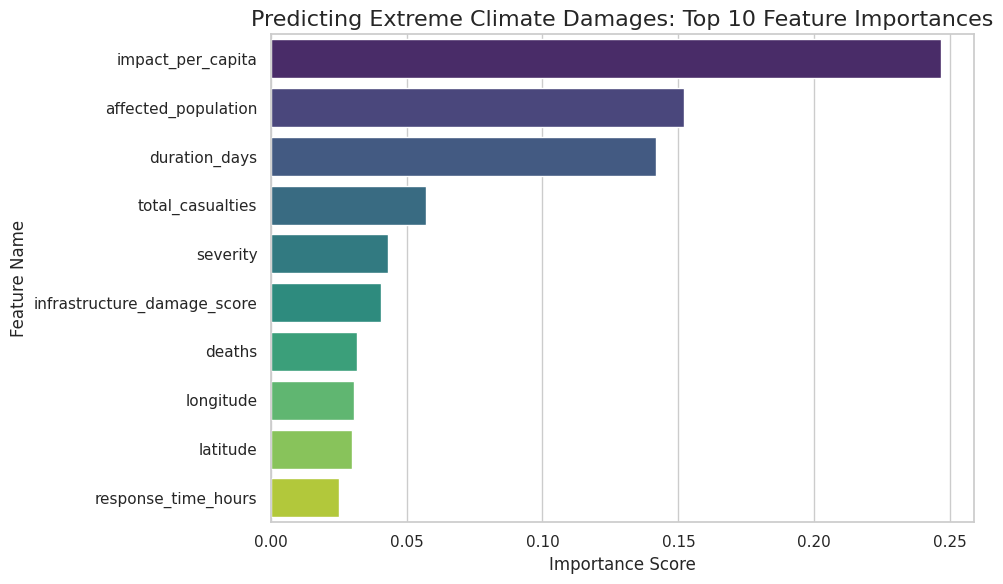

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importances.head(10), 
    x='Importance', 
    y='Feature', 
    hue='Feature',      # 指定用 Feature 來決定顏色
    palette='viridis', 
    legend=False        # 關閉自動產生的圖例
)

#  換上隨機森林成果圖的專業英文標題與標籤
plt.title('Predicting Extreme Climate Damages: Top 10 Feature Importances', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

### 從模型的Importance Score觀察到:
1. 人本指標大於物理指標
從隨機森林模型的特徵重要性可以看到，前兩名決定極端災損的關鍵，並不是氣候本身的物理條件（如 severity 嚴重度僅排第五），而是**人本指標**——人均衝擊 (impact_per_capita) 與 受災人口 (affected_population)。這證明了極端氣候的破壞力，高度取決於它是否發生在人類居住稠密、且經濟防禦力脆弱的區域。」

2. 呼應前面的統計發現
值得注意的是，第三名是持續天數 (duration_days)。雖然我們在步驟二的相關性熱力圖中，發現 duration_days 與災損的『線性相關』不高，但隨機森林作為非線性模型，卻成功抓出了它高達約 14% 的特徵重要性！這代表天災持續時間對災損的影響可能是非線性的（可能跨過某個臨界天數後，災損才會呈指數型噴發），而樹狀模型成功捕捉到了這個關鍵特徵。

3. 地理與防禦機制的次要影響
最後，地理位置（longitude 經度、latitude 緯度）以及政府的響應時間（response_time_hours）雖然排在後半段，但它們依然提供了穩定的預測資訊。特別是救援響應時間（亮黃色長條），雖然分數最低，但在微調模型邊界時仍具備不可忽視的調整作用。